In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import poisson, gamma
from empiricaldist import Pmf

sns.set_style('darkgrid')

## 8.2 The Poisson Distribution

In [2]:
lamda_ = 1.4
dist = poisson(lamda_)
dist.pmf(4)

0.039471954028253146

Text(0.5, 1.0, 'Distribution of goals scored')

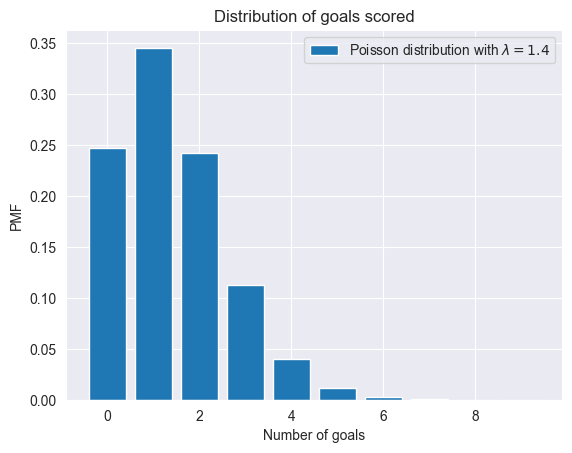

In [9]:
def make_poisson_pmf(lambda_, qs):
    """Make a Pmf of a Poisson distribution."""
    ps = poisson(lambda_).pmf(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf


lambda_ = 1.4
goals = np.arange(10)
pmf_goals = make_poisson_pmf(lambda_, goals)
pmf_goals.bar(label=r'Poisson distribution with $\lambda=1.4$')
plt.xlabel('Number of goals')
plt.ylabel('PMF')
plt.legend()
plt.title('Distribution of goals scored')

## 8.3 The Gamma Distribution

Mean of the prior distribution: 1.41


Text(0.5, 1.0, 'Prior Distribution of lambda')

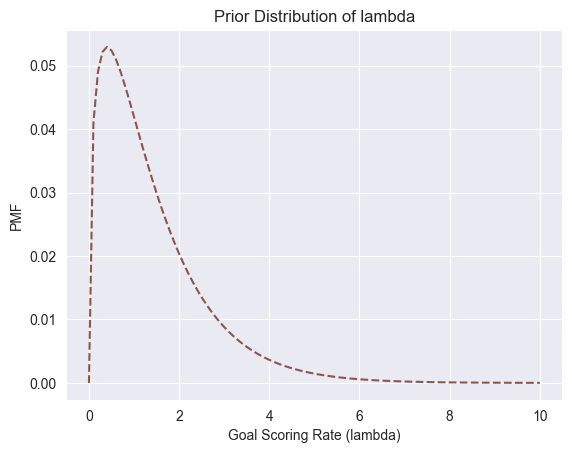

In [ ]:
alpha = 1.4
qs = np.linspace(0, 10, 101)
ps = gamma(alpha).pdf(qs)

prior = Pmf(ps, qs)
prior.normalize()

print(f'Mean of the prior distribution: {prior.mean():.2f}')

prior.plot(ls='--', label='prior', color='C5')
plt.xlabel('Goal Scoring Rate (lambda)')
plt.ylabel('PMF')
plt.title('Prior Distribution of lambda')

## 8.4 The Update

Text(0.5, 1.0, 'Prior and Posterior Distributions of lambda')

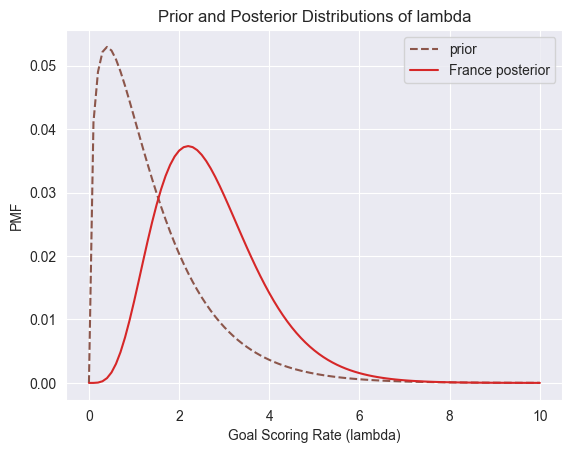

In [28]:
def update_poisson(prior: Pmf, data: int) -> None:
    prior = prior.copy()
    """Update Pmf with a Poisson likelihood."""
    hypothesis = prior.qs
    likelihood = poisson(mu=hypothesis).pmf(data)
    prior *= likelihood
    prior.normalize()
    return prior


france_posterior = update_poisson(prior, 4)

prior.plot(ls='--', label='prior', color='C5')
france_posterior.plot(label='France posterior', color='C3')
plt.legend()
plt.xlabel('Goal Scoring Rate (lambda)')
plt.ylabel('PMF')
plt.title('Prior and Posterior Distributions of lambda')

Text(0.5, 1.0, 'Prior and Posterior Distributions of lambda')

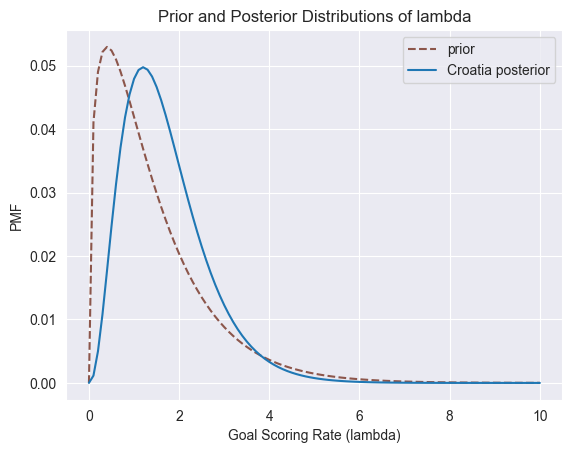

In [29]:
croatia_posterior = update_poisson(prior, 2)

prior.plot(ls='--', label='prior', color='C5')
croatia_posterior.plot(label='Croatia posterior', color='C0')
plt.legend()
plt.xlabel('Goal Scoring Rate (lambda)')
plt.ylabel('PMF')
plt.title('Prior and Posterior Distributions of lambda')

In [21]:
print(croatia_posterior.mean(), france_posterior.mean())

1.6999765866755225 2.699772393342308


## 8.5 Probability of Superiority

In [23]:
def prob_gt(pmf1, pmf2):
    """Compute the probability of superiority."""
    total_prob = 0
    for q1, p1 in pmf1.items():
        for q2, p2 in pmf2.items():
            if q1 > q2:
                total_prob += p1 * p2
    
    return total_prob

prob_gt(france_posterior, croatia_posterior)

0.7499366290930155

In [22]:
Pmf.prob_gt(france_posterior, croatia_posterior)

0.7499366290930174

## 8.6 Predicting the Rematch

In [39]:
prior.qs

array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. ])

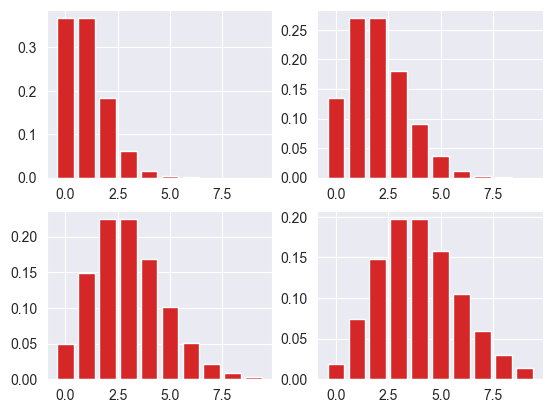

In [43]:
poisson_pmfs = [make_poisson_pmf(assumed_lambda, goals) for assumed_lambda in prior.qs]
for i, index in enumerate([10, 20, 30, 40]):
    plt.subplot(2, 2, i+1)
    assumed_lambda = prior.qs[index]
    hypothesis_dist = poisson_pmfs[index]
    hypothesis_dist.bar(label=f'$\lambda$ = {assumed_lambda}', color='C3')

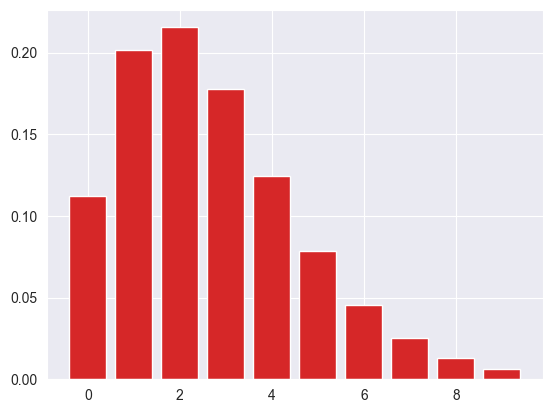

In [44]:
def make_mixture(
    hypothesis_dist: Pmf, 
    conditional_dists: list[Pmf]
):
    """Make a mixture of distributions.

    hypothesis_dist: mapping from each hypothesis to its probability
            (or it can be a sequence of probabilities)
    conditional_dists: sequence of Pmfs, each representing
                a conditional distribution for one hypothesis

    returns: Pmf representing the mixture
    """
    df = pd.DataFrame(conditional_dists).fillna(0).transpose()
    df *= np.array(hypothesis_dist)
    total = df.sum(axis=1)
    return Pmf(total)

predicted_france_goals = make_mixture(france_posterior, poisson_pmfs)
predicted_france_goals.bar(color='C3', label='France')

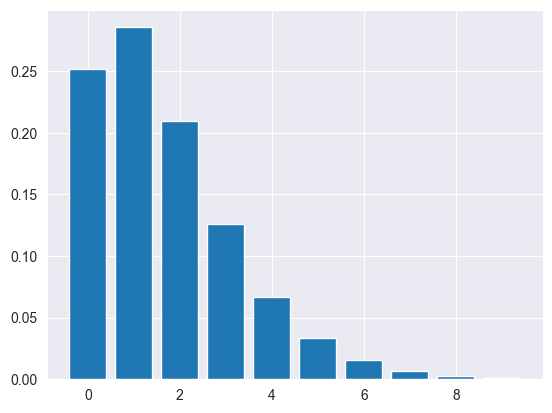

In [45]:
predicted_croatia_goals = make_mixture(croatia_posterior, poisson_pmfs)
predicted_croatia_goals.bar(color='C0', label='Croatia')

In [47]:
france_win_prob = Pmf.prob_gt(predicted_france_goals, predicted_croatia_goals)
france_win_prob

0.5703522415934519

In [48]:
france_lose_prob = Pmf.prob_gt(predicted_croatia_goals, predicted_france_goals)
france_lose_prob

0.26443376257235873

In [49]:
tie_prob = Pmf.prob_eq(predicted_france_goals, predicted_croatia_goals)
tie_prob

0.16521399583418947

In [ ]:
france_win_prob + tie_prob/2